In [7]:
import matplotlib.pyplot as plt
import mplhep as hep
import pandas as pd
from PIL import Image
import importlib
import numpy as np
import awkward as ak
hep.style.use(hep.style.CMS)
import run

# Read parquet
simName = "TrgCenter"
data = {}
for b in run.Brange:
    B = f"{b:02d}"
    data[f"B{B}"] = ak.from_parquet(f"parquet/{simName}_B{B}.parquet")
    print(f"parquet/{simName}_B{B}.parquet was successfully added to data[B{B}].")

print("\nConverting data to an awkward array...")
data = ak.Record({
    f"B{b:02d}": data[f"B{b:02d}"]
    for b in run.Brange
})
print("Done!")

parquet/TrgCenter_B03.parquet was successfully added to data[B03].
parquet/TrgCenter_B04.parquet was successfully added to data[B04].
parquet/TrgCenter_B05.parquet was successfully added to data[B05].
parquet/TrgCenter_B06.parquet was successfully added to data[B06].
parquet/TrgCenter_B07.parquet was successfully added to data[B07].
parquet/TrgCenter_B08.parquet was successfully added to data[B08].
parquet/TrgCenter_B09.parquet was successfully added to data[B09].
parquet/TrgCenter_B10.parquet was successfully added to data[B10].

Converting data to an awkward array...
Done!


In [9]:
data.B03

<Record {esc: {...}, prod: {...}, ...} type='{esc: {PiPlus: var * var * {id...'>

In [8]:
np.unique(ak.flatten(data.esc.PiPlus.run))

<Array [1] type='1 * int64'>

Text(0.5, 1.0, 'Pions angular distribution for 8 GeV beam [Inconel target]')

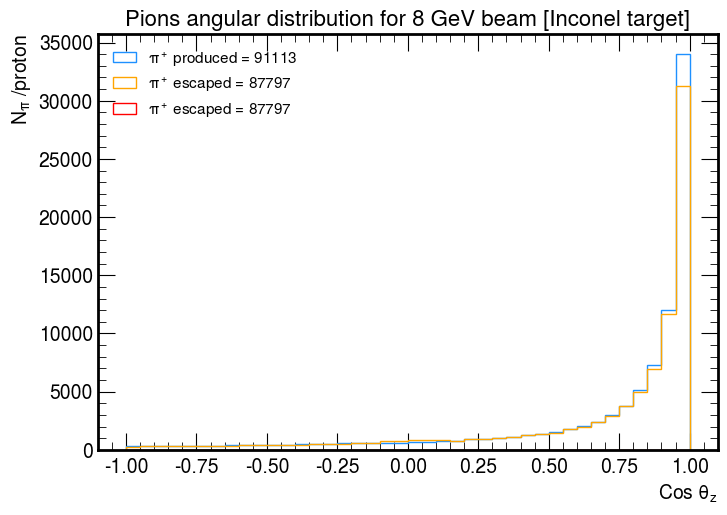

In [14]:
bins = np.linspace(-1,1,41)
plt.subplots(1, 1, figsize=(8, 5.4))
plt.hist(ak.flatten(data.prod.PiPlus.cz), bins, histtype="step", color='dodgerblue',
        label=f'$\\pi^+$ produced = {ak.sum(ak.num(data.prod.PiPlus.cz))}')
plt.hist(ak.flatten(data.esc.PiPlus.cz), bins, histtype="step", color='orange',
        label=f'$\\pi^+$ escaped = {ak.sum(ak.num(data.esc.PiPlus.cz))}')
plt.hist(ak.flatten(data.det1.PiPlus.cz), bins, histtype="step", color='red',
        label=f'$\\pi^+$ escaped = {ak.sum(ak.num(data.esc.PiPlus.cz))}')
# plt.hist(ak.flatten(data.det1.PiPlus.cz), bins, histtype="step", color='orange',
#         label=f'$\\pi^-$ at det1 = {ak.sum(ak.num(data.det1.PiPlus.cz))}')

plt.legend(fontsize=11)
plt.tick_params(axis='both', labelsize=14)
plt.xlabel('Cos $\\theta_z$', fontsize=14)
plt.ylabel(r'$N_{\pi}$ /proton', fontsize=14)
# plt.ylim(0,0.0033)
# plt.yscale('log')
plt.title(f'Pions angular distribution for {data.metadata.beam_energy_GeV} GeV beam [{data.metadata.target.material} target]', fontsize=16)

In [26]:
for b in range(3,4):
    if b < 10:
        B = f"0{str(b)}"
    else:
        B = str(b)
    print(B)
    print(f"B = {b:<2}, done!")

03
B = 3 , done!


In [25]:
for r in range(1,2):
    print(r)

1
